<a href="https://colab.research.google.com/github/Losorioh/Radiografia_Digital/blob/V.Bootcamp/Radiograf%C3%ADa_Digital_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Preparación de datos**

- Transformación de datos (asignación de formatos)
- Asignación de nombres clave en columnas
- Importación de BD secundarias
- Creación de 'data dictionary' (estructuración del espacio de trabajo)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np # Aritmética

In [ ]:
#Creación Data Frame de la BD_ICC 2019-2024

df_ICC = pd.read_excel('/content/drive/MyDrive/Proyecto - Analisis de datos/BD/MODIFICACIONES/Base-de-datos-ICC-2024 (v.01).xlsx',
                       sheet_name='Valor_normalizado')
df_ICC

In [ ]:
df_ICC.info ()

In [ ]:
#Cambiar el formato de float64 a float32

df_ICC = df_ICC.astype({'TIC-1-1':'float32','TIC-1-2':'float32','TIC-1-3':'float32',
                        'TIC-1-4':'float32','TIC-1':'float32','TIC-2-1':'float32',
                        'TIC-2-2':'float32','TIC-2-3':'float32',
                        'TIC-2':'float32','TIC':'float32'})
df_ICC = df_ICC.astype({'INN-1-1':'float32','INN-1-2':'float32','INN-1-3':'float32',
                        'INN-1-4':'float32','INN-1-5':'float32','INN-1':'float32','INN-2-1':'float32',
                        'INN-2-2':'float32','INN-2-2':'float32','INN-2-3':'float32',
                        'INN-2-4':'float32','INN-2':'float32','INN':'float32','Puntaje general':'float32'})

df_ICC = df_ICC.astype({'Año':'object'})
df_ICC.info()


In [35]:
#Cambiar los nombres de las columnas

df_ICC = df_ICC.rename(columns={df_ICC.columns[11]:'TIC_Total',df_ICC.columns[23]:'INN_Total'})
df_ICC


df_ICC = df_ICC.rename(columns={df_ICC.columns[0]:'Ciudad'})
df_ICC

df_ICC.info()

<class 'pandas.core.frame.DataFrame'>
Index: 192 entries, 0 to 191
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ciudad           192 non-null    object 
 1   Año              192 non-null    object 
 2   TIC-1-1          192 non-null    float32
 3   TIC-1-2          192 non-null    float32
 4   TIC-1-3          192 non-null    float32
 5   TIC-1-4          192 non-null    float32
 6   TIC-1            192 non-null    float32
 7   TIC-2-1          192 non-null    float32
 8   TIC-2-2          192 non-null    float32
 9   TIC-2-3          192 non-null    float32
 10  TIC-2            192 non-null    float32
 11  TIC_Total        192 non-null    float32
 12  INN-1-1          192 non-null    float32
 13  INN-1-2          192 non-null    float32
 14  INN-1-3          192 non-null    float32
 15  INN-1-4          192 non-null    float32
 16  INN-1-5          192 non-null    float32
 17  INN-1            192 

In [ ]:
#Revisar si tiene valores nulos

df_ICC.isnull()

df_ICC.isnull().count()

In [74]:
pd.unique(df_ICC['Ciudad'])

array(['Arauca', 'Armenia', 'Barranquilla AM', 'Bogotá D.C.',
       'Bucaramanga AM', 'Cali AM', 'Cartagena', 'Cúcuta AM', 'Florencia',
       'Ibagué', 'Inírida', 'Leticia', 'Manizales AM', 'Medellín AM',
       'Mitú', 'Mocoa', 'Montería', 'Neiva', 'Pasto', 'Pereira AM',
       'Popayán', 'Puerto Carreño', 'Quibdó', 'Riohacha', 'San Andrés',
       'San José del Guaviare', 'Santa Marta', 'Sincelejo', 'Tunja',
       'Valledupar', 'Villavicencio', 'Yopal'], dtype=object)

# **Exploración de datos**

- Gráficas de comparación (Resultados TIC e innovación) *
1. Resultados de TIC e Innovación para las 32 ciudades de colombia
2. Ciudades principales (Top 5) en TIC e Innovación
3. Ciudad por encima y por debajo del promedio nacional
4. Correlación entre innovación y TIC
5. Comportamiento de las regiones (distribución regional)

- Gráficas de tendencias: series de tiempo

1. Ciudades con un comportamiento positivo en el tiempo
2. Ciudades con bajo rendimiento en ambos pilares
3. Lideres en los pilares
4. Los subpilares con mayor y menor puntaje


In [ ]:
df_ICC.describe()

In [ ]:
df_max_TIC = df_ICC.groupby(['Ciudad', 'TIC_Total', 'Año']).max()  # Agrupar por Ciudad, TIC_Total y Año
df_max_TIC_sorted = df_max_TIC.sort_values(by='TIC_Total', ascending=False)  # Ordenar por TIC_Total
df_top_5_by_year_TIC = df_max_TIC_sorted.groupby('Año').head(5)

df_top_5_by_year_TIC.sort_values(by='Año') # Muestra 1: Top 5 ciudades principales por año



In [87]:
df_max_ICC = df_ICC.groupby(['Ciudad', 'INN_Total', 'Año']).max()  # Agrupar por Ciudad, TIC_Total y Año
df_max_ICC_sorted = df_max_ICC.sort_values(by='INN_Total', ascending=False)  # Ordenar por TIC_Total
df_top_5_by_year_ICC = df_max_ICC_sorted.groupby('Año').head(5)

df_top_5_by_year_ICC.sort_values(by='Año') # Muestra 1: Top 5 ciudades principales por año



,,,TIC-1-1,TIC-1-2,TIC-1-3,TIC-1-4,TIC-1,TIC-2-1,TIC-2-2,TIC-2-3,TIC-2,TIC_Total,...,INN-1-3,INN-1-4,INN-1-5,INN-1,INN-2-1,INN-2-2,INN-2-3,INN-2-4,INN-2,Puntaje general
Ciudad,INN_Total,Año,,,,,,,,,,,,,,,,,,,,,
Cali AM,3.512194,2019,7.113858,0.530310,7.231060,8.592928,5.867039,2.477635,2.893195,5.390888,3.587240,4.727139,...,3.468171,6.771300,3.255880,3.799383,2.678558,3.570335,1.893790,4.757339,3.225005,6.017328
Tunja,4.236894,2019,8.079403,0.408603,6.663433,7.126197,5.569409,8.311933,7.935920,9.545588,8.597814,7.083611,...,10.000000,5.739910,2.439785,6.593401,0.929413,4.026246,0.826690,1.739196,1.880386,6.199191
Manizales AM,4.414492,2019,6.354440,0.427073,7.059518,7.317939,5.289742,4.584951,6.032754,10.000000,6.872568,6.081155,...,6.390936,4.349776,3.186455,5.650098,2.892098,4.872253,1.429138,3.522053,3.178885,5.793851
Bogotá D.C.,5.750514,2019,8.544282,0.649841,9.568893,9.513601,7.069155,4.008368,4.857068,8.171128,5.678855,6.374005,...,4.727586,9.596413,2.663644,5.372347,4.737993,6.373097,5.484396,7.919239,6.128681,7.096984
Medellín AM,5.048198,2019,8.137670,0.588232,7.074534,7.415284,5.803930,3.579411,3.549590,6.906281,4.678428,5.241179,...,4.865892,5.739910,2.768490,4.368591,4.558207,3.320966,7.555948,7.476102,5.727806,6.336383
Pereira AM,4.114731,2020,7.642505,0.816985,7.316308,8.935357,6.177789,5.361490,6.549965,4.344975,5.418810,5.798299,...,3.531753,5.919282,4.277416,3.780247,5.337512,5.298850,3.758503,3.401997,4.449215,5.874355
Bogotá D.C.,5.962754,2020,8.520530,1.455998,9.568893,9.513601,7.264756,3.873959,4.968458,8.314129,5.718849,6.491802,...,5.685036,9.596413,2.663644,5.801157,5.808253,5.764276,4.414834,8.510042,6.124351,7.007647
Tunja,4.755069,2020,8.401765,0.765649,6.663433,7.126197,5.739261,8.401212,7.443645,7.940377,7.928411,6.833836,...,8.389235,5.739910,2.439785,7.125002,4.546957,1.969755,0.808881,2.214949,2.385135,6.270664
Medellín AM,5.602192,2020,8.328507,0.994385,7.074534,7.415284,5.953177,3.580450,3.577465,7.068487,4.742134,5.347656,...,5.754318,5.739910,2.768490,4.723172,6.222060,3.675565,7.906237,8.120985,6.481212,6.355359


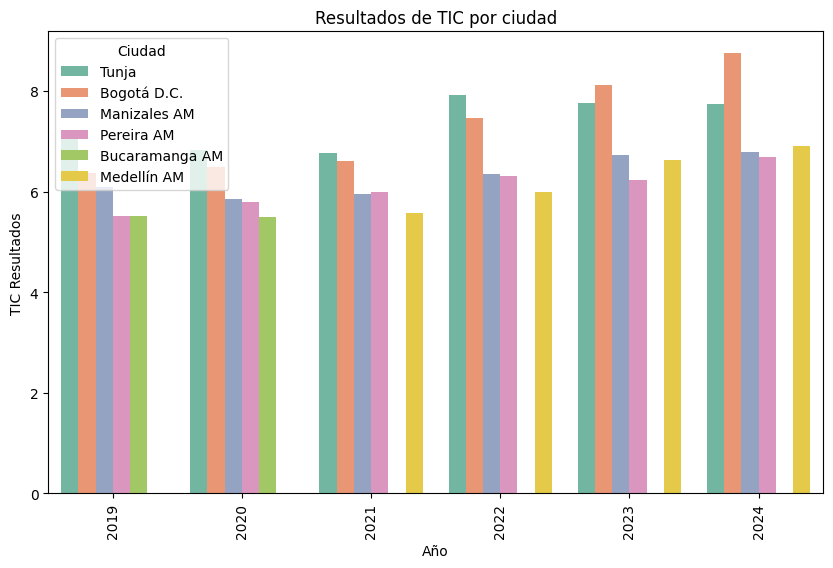

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))  # Ajustar el tamaño de la figura si es necesario
sns.barplot(data=df_top_5_by_year_TIC,x='Año', y='TIC_Total', hue='Ciudad',palette='Set2')

plt.title('Resultados de TIC por ciudad')
plt.xlabel('Año')
plt.ylabel('TIC Resultados')
plt.xticks(rotation=90)  # Rotar las etiquetas del eje X si es necesario
plt.show()

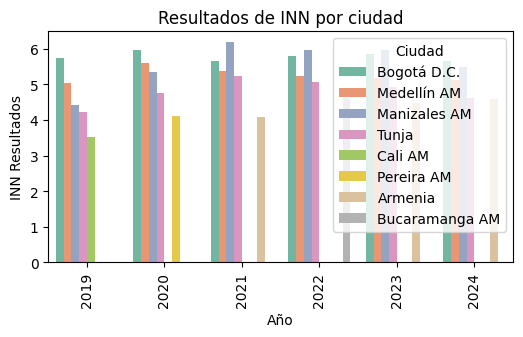

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))  # Ajustar el tamaño de la figura si es necesario
sns.barplot(data=df_top_5_by_year_ICC,x='Año', y='INN_Total', hue='Ciudad',palette='Set2')

plt.title('Resultados de INN por ciudad')
plt.xlabel('Año')
plt.ylabel('INN Resultados')
plt.xticks(rotation=90)  # Rotar las etiquetas del eje X si es necesario
plt.show()

In [ ]:
df_filtrado = df_ICC[df_ICC['Ciudad'].isin(['Manizales AM', 'Bogotá D.C.','Medellín AM'
])]
df_filtrado.sort_values(by='Ciudad')





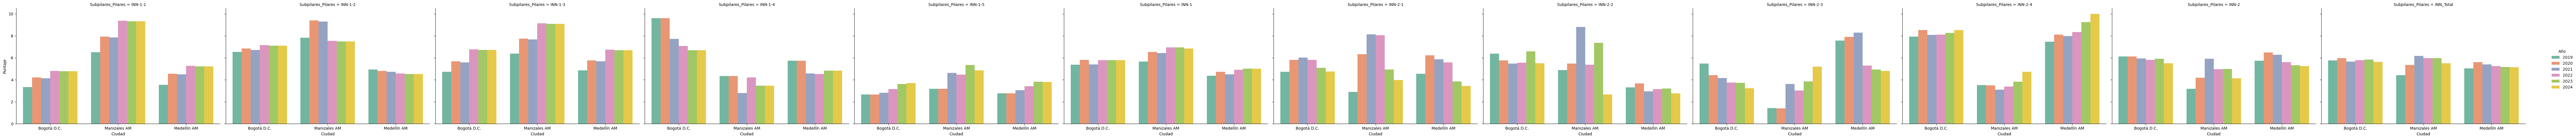

In [86]:
df_melted_ICC = df_filtrado.melt (
    id_vars = ['Ciudad','Año'],
    value_vars = ['INN-1-1','INN-1-2','INN-1-3','INN-1-4','INN-1-5','INN-1',
                  'INN-2-1','INN-2-2','INN-2-3','INN-2-4','INN-2','INN_Total'],
    var_name = 'Subpilares_Pilares',
    value_name = 'Puntaje'

)

df_melted_ICC


import seaborn as sns

sns.catplot(
    data=df_melted_ICC,
    x='Ciudad',
    y='Puntaje',
    hue='Año',
    col='Subpilares_Pilares',
    kind='bar',  # Gráfico de barras
    palette='Set2',  # Paleta de colores
    height=5,  # Altura de cada gráfico
    aspect=1.5  # Relación de aspecto (ancho/alto)
)





In [ ]:
df_filtrado = df_ICC[df_ICC['Ciudad o AM'].isin(['Arauca','Armenia','Barranquilla AM',
                                                 'Bogotá D.C.','Bucaramanga AM','Cali AM','Cartagena',
                                                 'Cúcuta AM''Florencia','Ibagué','Yopal'
])]
df_filtrado

In [ ]:
df_filtrado.info()

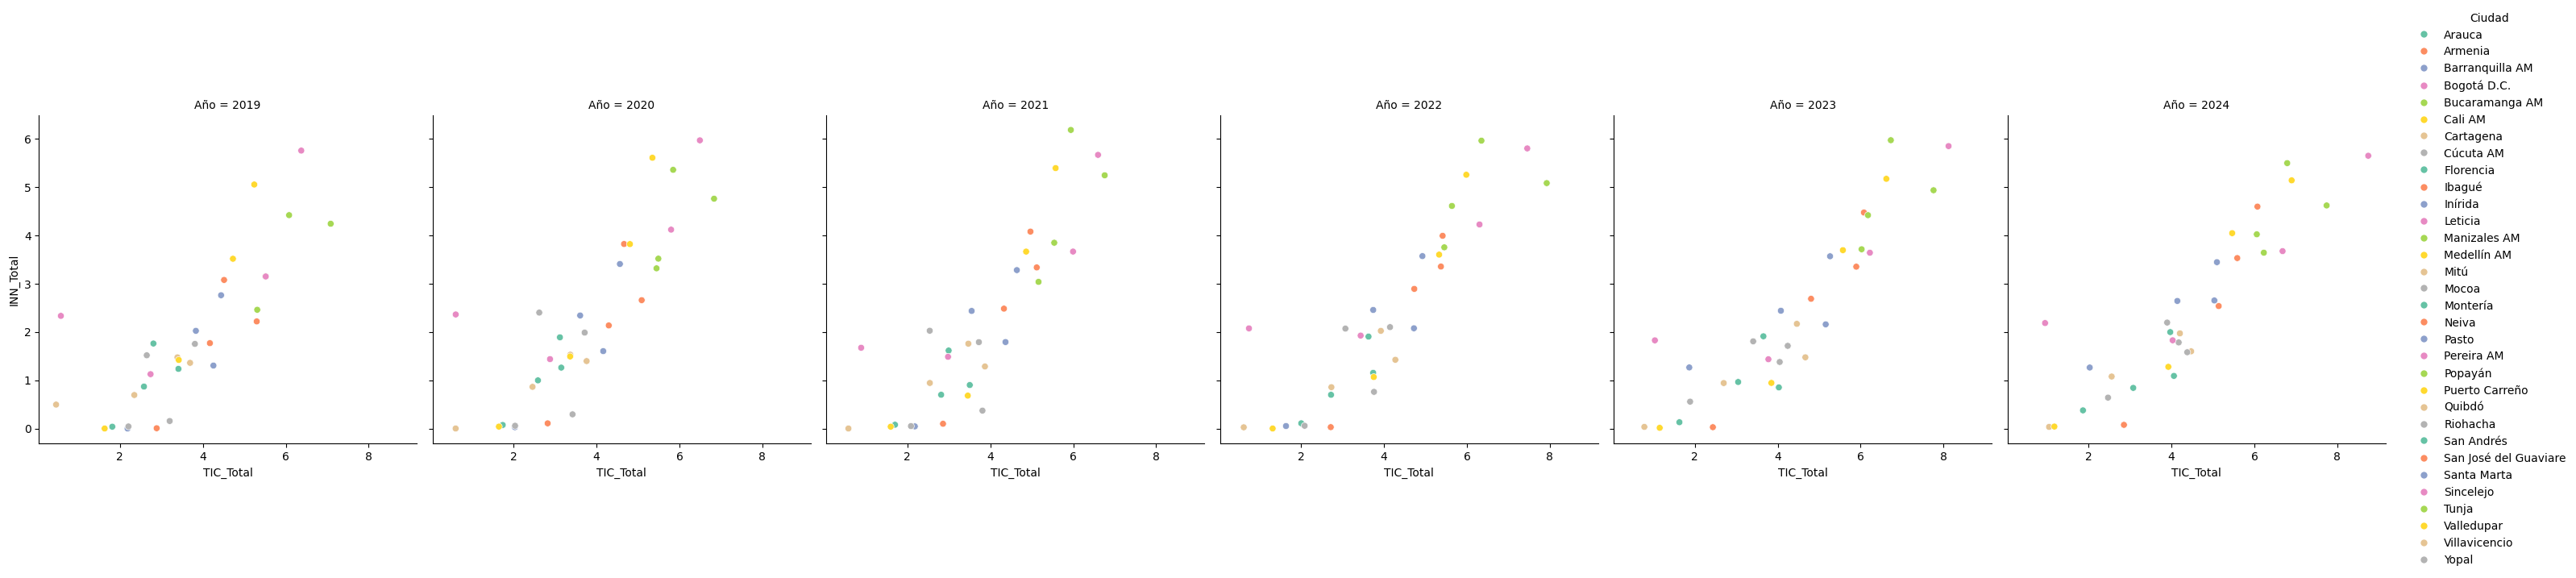

In [98]:
df_correlacion_TIC_INN = df_ICC[['Ciudad', 'Año', 'TIC_Total', 'INN_Total']]
df_correlacion_TIC_INN

sns.relplot(
    data=df_correlacion_TIC_INN,
    x='TIC_Total',
    y='INN_Total',
    hue='Ciudad',
    col='Año',  # Divide el gráfico por el valor de 'Año'
    kind='scatter',  # Especifica que el tipo de gráfico es de dispersión
    palette='Set2'  # Paleta de colores
)





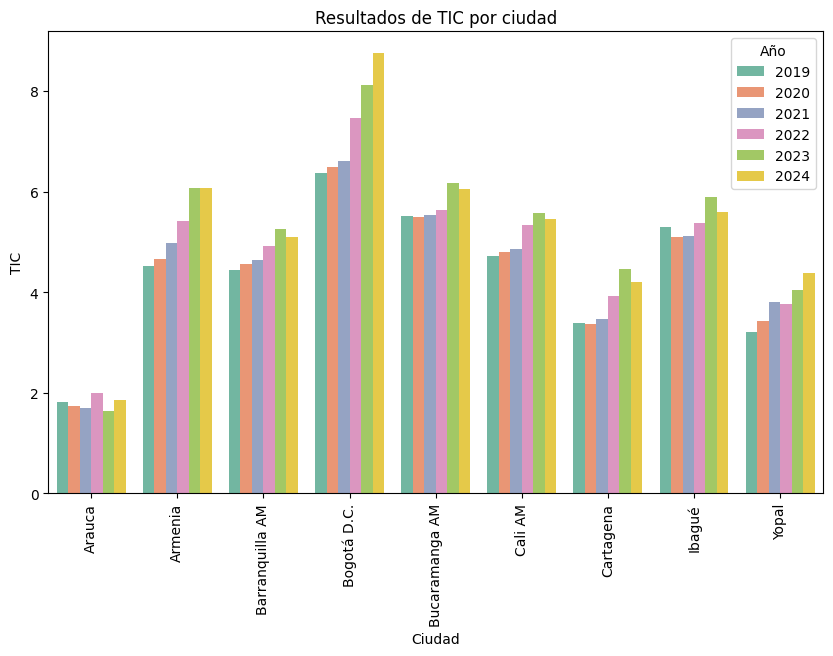

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))  # Ajustar el tamaño de la figura si es necesario
sns.barplot(data=df_filtrado,x='Ciudad o AM', y='TIC', hue='Año',palette='Set2')

plt.title('Resultados de TIC por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('TIC')
plt.xticks(rotation=90)  # Rotar las etiquetas del eje X si es necesario
plt.show()

